# 1 — Half-Bridge Converter Modeling

> **Goal.** Derive the small-signal model of the half-bridge and show
> that it is **identical to the forward's** — same $G_{vd}(s)$, same
> $G_{vg}(s)$, same $Z_{out}(s)$, no RHP zero. What changes is the
> IMPLEMENTATION: two switches alternating around a rail-split input,
> a center-tapped secondary, dead-time to prevent shoot-through, and
> output ripple at **$2 f_{sw}$** (twice the per-switch frequency).

**Prerequisites**

- Forward modeling notebook (`projects/converters/forward/`). The
  half-bridge's average model is literally the forward's.
- Buck modeling notebook (`projects/converters/buck/`). The forward
  is buck-derived, so the half-bridge is too.

**What you'll be able to do at the end**

1. Identify the half-bridge on a schematic by the rail-split input
   and the two alternating switches.
2. Write the 4-phase switched model (S1-on, dead, S2-on, dead) and
   recognize that averaging it produces the forward's equations.
3. Explain why $V_o = n \cdot V_g \cdot D$ even though the primary
   sees only $V_g/2$ (the $1/2$ from rail-split exactly cancels the
   $2$ from both half-cycles being rectified).
4. State the dead-time / shoot-through constraint and how it caps
   the duty at $D_{max} \approx 0.45$.
5. Predict the output ripple frequency: $2 f_{sw}$.
6. Argue why the half-bridge replaces the forward as the dominant
   isolated topology beyond a few tens of watts: lower switch stress,
   no reset winding, smaller output filter for the same ripple.


## Setup

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))

import numpy as np
from scipy import signal
import matplotlib.pyplot as plt

from half_bridge_model import (
    HalfBridgeParams,
    half_bridge_state_space,
    control_to_output_tf,
    line_to_output_tf,
    output_impedance_tf,
    operating_point_report,
)

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3


## 1. The half-bridge topology

```
       V_g+ ----+---- S1 (high-side) --+
                |                      |
               C1                      |
                |                      |
                +-----------------+    +----- sw_node (mid)  ── primary ──┐
                |                 |    |                                   |
               C2                 |    |                                   )||(
                |                 |    |                                   )||( transformer
              V_g/2 (midpoint) ───+    |                                   )||(
                                       |                                   |
       V_g- ----+---- S2 (low-side) ---+                       gnd_pri ────┘

       (rail-split capacitor pair       (alternating switches:
        produces V_g/2 midpoint)         S1 on first half, S2 second half)


Secondary (center-tapped):
                      ┌── D1 ── L ──┬── V_o
                      │             │
                      ├── (tap) ────┤   C ─── R
                      │             │
                      └── D2 ── L ──┴── gnd_sec
```

- **Input rail-splitter**: C1 and C2 are large series caps across
  $V_g$; their midpoint sits at $V_g/2$ (assuming balanced
  capacitance and equal switching duty).
- **High-side switch S1** (during first half-period): connects
  switching node to $V_g$. Primary sees $V_g - V_g/2 = +V_g/2$.
- **Low-side switch S2** (during second half-period): connects
  switching node to ground. Primary sees $0 - V_g/2 = -V_g/2$.
- **Dead-time** between S1-off and S2-on: BOTH switches off, primary
  floats. Without this, both switches briefly conducting would short
  $V_g$ through them ("shoot-through") and destroy the silicon.
- **Center-tapped secondary**: two diodes rectify the AC primary
  swing into a DC pulse train at twice the per-switch frequency.

### 1.1 The per-switch duty convention

$D$ is the **on-time fraction of ONE switch over a full period**, so
$D \in [0, 0.5]$. The effective conduction fraction at the output
is $2D$ (both half-cycles contribute equally after rectification).

### 1.2 Energy routing — half-bridge vs forward vs flyback

| Phase | Half-bridge | Forward | Flyback |
|---|---|---|---|
| S1/S2 ON | primary swings ±V_g/2; secondary energized through D1 or D2; filter L charged | primary energized; D1 on, D2 off; filter L charged | primary stores energy in L_m; secondary disconnected |
| Dead-time | both switches off; filter L freewheels through D1/D2 | — | — |
| Both OFF (forward) | — | filter L freewheels through D2 | — |
| Switch OFF (flyback) | — | — | secondary releases stored energy through diode |

Both half-bridge and forward are **buck-derived** — energy is
transferred forward through the transformer in real time, filter L-C
handles storage. Flyback is buck-boost-derived (different family,
RHP zero).


## 2. Switched (instantaneous) model — 4 phases per period

A full switching period $T_s = 1/f_{sw}$ splits into four phases:

```
|<------ T_s = 1 / f_sw ----------->|
|<-- D·T_s -->|     |<-- D·T_s -->|
+-------------+-----+-------------+-----+
|     S1      |dead |     S2      |dead |
+-------------+-----+-------------+-----+
0          D·T_s  T_s/2        T_s/2+D·T_s   T_s
```

### 2.1 Phase 1: S1 on, S2 off ($0 \le t < D \cdot T_s$)

Primary sees $+V_g/2$ → secondary sees $+n \cdot V_g/2$. D1 forward-
biased, D2 reverse-biased. Filter L-C input sees $n \cdot V_g/2$:

$$
L \cdot \frac{di_L}{dt} = n \cdot V_g/2 - v_o
\qquad
C \cdot \frac{dv_o}{dt} = i_L - \frac{v_o}{R}
$$

Wait — that says the L-C input is $n V_g/2$, not $n V_g$. Where does
the $V_o = n V_g D$ formula (not $n V_g D / 2$) come from? Read on.

### 2.2 Phase 2: dead-time after S1 ($D T_s \le t < T_s/2$)

Both switches off. Primary floats; transformer doesn't drive
secondary. **But the filter inductor must keep its current** — both
secondary diodes freewheel (D1 and D2 simultaneously, splitting
$i_L/2$ each through the center tap), and the L-C input sees 0:

$$
L \cdot \frac{di_L}{dt} = -v_o
\qquad
C \cdot \frac{dv_o}{dt} = i_L - \frac{v_o}{R}
$$

### 2.3 Phase 3: S2 on, S1 off ($T_s/2 \le t < T_s/2 + D T_s$)

Primary sees $-V_g/2$ → secondary sees $-n V_g/2$. The center-tap
rectifier **flips the sign**: D2 now forward-biases, D1 reverse-
biases. From the filter's perspective, the input voltage is **the
same magnitude as in phase 1**:

$$
L \cdot \frac{di_L}{dt} = n \cdot V_g/2 - v_o
\qquad
C \cdot \frac{dv_o}{dt} = i_L - \frac{v_o}{R}
$$

The center-tap rectifier turns ±V_g/2 on the primary into +V_g/2 on
the filter side — that's the "2× effective conduction" mentioned
earlier.

### 2.4 Phase 4: dead-time after S2 ($T_s/2 + D T_s \le t < T_s$)

Same as phase 2: both switches off, filter freewheels through both
diodes, L-C input sees 0.

### 2.5 So why is the average $V_o = n V_g D$ (not $n V_g D / 2$)?

Take the time average of the filter input voltage over one $T_s$:

$$
\bar v_{Lin} = \frac{1}{T_s} \int_0^{T_s} v_{Lin}(t)\,dt
= \frac{1}{T_s}\Big[D T_s \cdot n V_g/2 + (T_s/2 - D T_s) \cdot 0
                  + D T_s \cdot n V_g/2 + (T_s/2 - D T_s) \cdot 0\Big]
= n V_g \cdot D
$$

The factor of $1/2$ from the rail-split is exactly cancelled by the
factor of $2$ from both half-cycles contributing. The filter sees the
same average voltage as if a forward converter with primary $V_g$ ran
at duty $D$.

That's why the small-signal model is identical to the forward's.


## 3. State-space averaging — same as the forward

Average all four phases (replacing $q_1 + q_2$ by $2 d$ effective):

$$\boxed{
\;\; L \cdot \frac{di_L}{dt} = d \cdot n \cdot V_g - v_o
\;\;}
$$

$$\boxed{
\;\; C \cdot \frac{dv_o}{dt} = i_L - \frac{v_o}{R}
\;\;}
$$

**Identical to the forward.** The single-switch forward and the
two-switch half-bridge are the same converter in the average model.

### 3.1 Steady-state

$$
V_o = n \cdot V_g \cdot D, \qquad I_L = V_o / R
$$

### 3.2 Dead-time / shoot-through constraint

The "reset winding" constraint of the forward becomes the
**dead-time** constraint of the half-bridge:

$$
D \cdot T_s + t_{dead} \le T_s / 2
\quad\Longleftrightarrow\quad
D \le \frac{1}{2} - \frac{t_{dead}}{T_s}
$$

For $t_{dead} = 100$ ns, $T_s = 10$ µs (100 kHz), this caps $D$ at
$0.49$. Production designs use $D_{max} \approx 0.45$ for safety
margin. **Same numerical cap as the forward** — but a different
physical mechanism.


In [2]:
params = HalfBridgeParams()
print(operating_point_report(params))
print()
params.assert_dead_time_ok()
print("✅  Dead-time / shoot-through constraint check passed.")


Half-bridge operating point
  V_g         =   48.000 V
  V_o         =    5.000 V
  n = N_s/N_p =   0.2500    (per half on secondary)
  D           =   0.4167     (= V_o / (n·V_g))
  D_max       =   0.4500     (must leave dead-time)
  R           =    2.500 Ω
  I_L         =    2.000 A   (= load current)
  P_out       =   10.000 W

Two-switch implementation
  f_sw  per switch =    100.0 kHz
  f_ripple output  =    200.0 kHz  (= 2·f_sw)
  Dead-time        =      100 ns

Rail-split input
  Each cap on the input bus holds V_g/2.
  Switch voltage stress (per switch off): 48 V
  (vs forward: 2·V_g during reset, vs full-bridge: V_g)

Filter dynamics (same as forward / buck)
  L           =   50.000 µH
  C           =  200.000 µF
  f_n         =   1591.5 Hz
  Q           =    5.000

Control headline
  Same as forward: NO RHP zero, voltage-mode is buck-easy.

✅  Dead-time / shoot-through constraint check passed.


## 4. Small-signal linearization — same as the forward

Perturb $i_L = I_L + \hat i_L$, $v_o = V_o + \hat v_o$, $d = D + \hat d$,
$v_g = V_g + \hat v_g$. Substitute and drop products:

$$
L \cdot \frac{d\hat i_L}{dt}
   = D \cdot n \cdot \hat v_g + n \cdot V_g \cdot \hat d - \hat v_o
$$

$$
C \cdot \frac{d\hat v_o}{dt}
   = \hat i_L - \frac{\hat v_o}{R}
$$

**No $\hat d$ term in the cap equation** → **no RHP zero**. Same as
the buck and the forward. The half-bridge inherits all of the
buck's control simplicity, just with twice the switches and a
rail-split input.


## 5. State-space matrices

$$
A = \begin{bmatrix}
0 & -1/L \\
1/C & -1/(R C)
\end{bmatrix},
\quad
B = \begin{bmatrix}
n V_g / L & n D / L \\
0 & 0
\end{bmatrix}
$$

$$
C = \begin{bmatrix} 0 & 1 \end{bmatrix},
\quad
D_{\rm feed} = \begin{bmatrix} 0 & 0 \end{bmatrix}
$$

Same matrices as the forward. The two-switch implementation
disappears completely in the average model.


In [3]:
A, B, C_mat, D_mat = half_bridge_state_space(params)
print("A ="); print(A); print()
print("B = [col 0: d̂   col 1: v̂_g]"); print(B); print()
print("C =", C_mat)
print("D (feedthrough) =", D_mat)
print()
eig = np.linalg.eigvals(A)
print(f"A eigenvalues: {eig}")
print(f"Pole magnitude (= ω_n) = {abs(eig[0]):.1f} rad/s "
      f"(expect {params.omega_n:.1f})")


A =
[[     0. -20000.]
 [  5000.  -2000.]]

B = [col 0: d̂   col 1: v̂_g]
[[240000.           2083.33333333]
 [     0.              0.        ]]

C = [[0. 1.]]
D (feedthrough) = [[0. 0.]]

A eigenvalues: [-1000.+9949.87437107j -1000.-9949.87437107j]
Pole magnitude (= ω_n) = 10000.0 rad/s (expect 10000.0)


## 6. Transfer functions

### 6.1 $G_{vd}(s)$

$$
G_{vd}(s) = \frac{n V_g}{LC} \cdot
\frac{1}{s^2 + s/(RC) + 1/(LC)}
$$

Same shape as the forward and buck. Second-order low-pass, no zeros,
no RHP zero.

### 6.2 $G_{vg}(s)$, $Z_{out}(s)$

$$
G_{vg}(s) = \frac{n D}{LC s^2 + L/R \cdot s + 1}
$$

$$
Z_{out}(s) = \frac{s L}{LC s^2 + L/R \cdot s + 1}
$$

Same as the forward.


In [4]:
Gvd = control_to_output_tf(params)
Gvg = line_to_output_tf(params)
Zout = output_impedance_tf(params)

print(f"Gvd(0)  = {Gvd.num[0] / Gvd.den[2]:.3f} V/duty  "
      f"(expect n·V_g = {params.n*params.V_g:.3f})")
print(f"Gvg(0)  = {Gvg.num[0] / Gvg.den[2]:.4f} V/V    "
      f"(expect n·D = {params.n*params.D:.4f})")
print()
if len(Gvd.num) > 1:
    print(f"Gvd zeros: {np.roots(Gvd.num)}")
else:
    print(f"Gvd zeros: NONE  (no RHP zero — buck-derived isolation)")
print(f"Gvd poles: {np.roots(Gvd.den)}")


Gvd(0)  = 12.000 V/duty  (expect n·V_g = 12.000)
Gvg(0)  = 0.1042 V/V    (expect n·D = 0.1042)

Gvd zeros: NONE  (no RHP zero — buck-derived isolation)
Gvd poles: [-1000.+9949.87437107j -1000.-9949.87437107j]


### 6.3 Bode plots

Same shape as the forward. The half-bridge's $G_{vd}$ rolls off at
-40 dB/dec past $f_n$ with phase finishing at -180°.


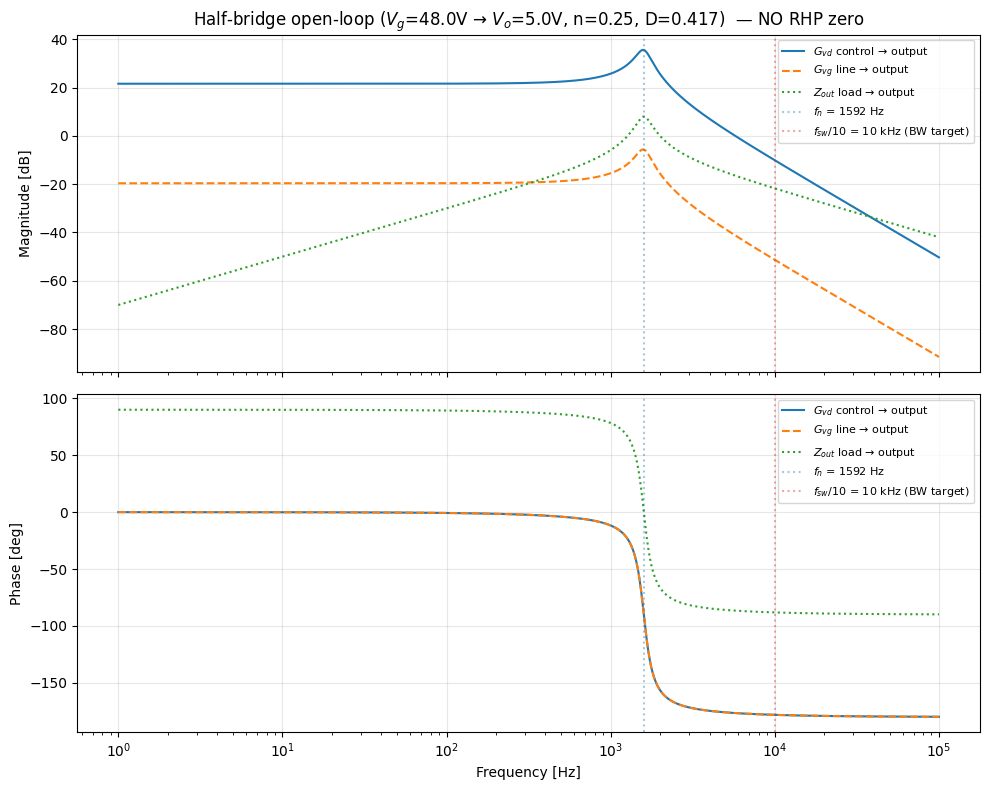

In [5]:
f = np.logspace(0, np.log10(params.f_sw), 1500)
w = 2 * np.pi * f

fig, (ax_mag, ax_ph) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
for tf, name, style in [
    (Gvd,  r"$G_{vd}$ control → output", "-"),
    (Gvg,  r"$G_{vg}$ line → output",    "--"),
    (Zout, r"$Z_{out}$ load → output",   ":"),
]:
    _, mag, ph = signal.bode(tf, w=w)
    ax_mag.semilogx(f, mag, style, label=name)
    ax_ph.semilogx(f, ph, style, label=name)

for ax in (ax_mag, ax_ph):
    ax.axvline(params.f_n, color="C0", linestyle=":", alpha=0.4,
               label=f"$f_n$ = {params.f_n:.0f} Hz")
    ax.axvline(params.f_sw / 10, color="C3", linestyle=":", alpha=0.4,
               label=f"$f_{{sw}}/10$ = {params.f_sw / 10 / 1e3:.0f} kHz (BW target)")
    ax.legend(loc="best", fontsize=8)

ax_mag.set_ylabel("Magnitude [dB]")
ax_ph.set_ylabel("Phase [deg]")
ax_ph.set_xlabel("Frequency [Hz]")
ax_mag.set_title(f"Half-bridge open-loop "
                 f"($V_g$={params.V_g}V → $V_o$={params.V_o}V, n={params.n}, "
                 f"D={params.D:.3f})  — NO RHP zero")
plt.tight_layout()
plt.show()


## 7. Step response — monotonic (same as forward)


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/scipy/signal/_ltisys.py:1972: RuntimeWarning: divide by zero encountered in matmul
  yout = squeeze(xout @ C.T) + squeeze(U @ D.T)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/scipy/signal/_ltisys.py:1972: RuntimeWarning: overflow encountered in matmul
  yout = squeeze(xout @ C.T) + squeeze(U @ D.T)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/scipy/signal/_ltisys.py:1972: RuntimeWarning: invalid value encountered in matmul
  yout = squeeze(xout @ C.T) + squeeze(U @ D.T)


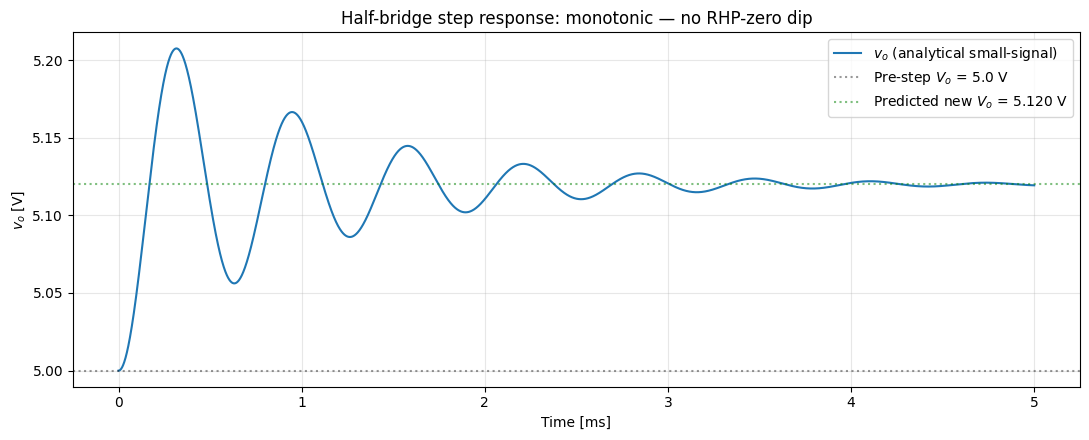

Pre-step  V_o = 5.0000 V
Final     v_o = 5.1193 V
Minimum   v_o = 5.0000 V (no dip — monotonic rise)


In [6]:
duty_step = 0.01
t = np.linspace(0, 5e-3, 5000)
_, y_step = signal.step(Gvd, T=t)
v_o_pred = params.V_o + duty_step * y_step

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(t * 1e3, v_o_pred, label="$v_o$ (analytical small-signal)")
ax.axhline(params.V_o, color="k", linestyle=":", alpha=0.4,
           label=f"Pre-step $V_o$ = {params.V_o} V")
ax.axhline(params.V_o + duty_step * params.n * params.V_g, color="g",
           linestyle=":", alpha=0.5,
           label=f"Predicted new $V_o$ = "
                 f"{params.V_o + duty_step * params.n * params.V_g:.3f} V")
ax.set_xlabel("Time [ms]")
ax.set_ylabel("$v_o$ [V]")
ax.set_title("Half-bridge step response: monotonic — no RHP-zero dip")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Pre-step  V_o = {params.V_o:.4f} V")
print(f"Final     v_o = {v_o_pred[-1]:.4f} V")
print(f"Minimum   v_o = {np.min(v_o_pred):.4f} V "
      f"(no dip — monotonic rise)")


## 8. Self-consistency checks

Same three rigorous checks. The state-space and the closed-form TFs
must match.


In [7]:
def _trim_near_zero(coeffs, rel_tol=1e-9):
    '''Strip leading near-zero coefficients (scipy.ss2tf noise).'''
    a = np.asarray(coeffs).flatten()
    if a.size == 0:
        return a
    threshold = rel_tol * np.max(np.abs(a))
    nz = np.argmax(np.abs(a) > threshold)
    return a[nz:]


Gvd_closed = control_to_output_tf(params)

# (1) Poles
ss_poles = sorted(np.linalg.eigvals(A), key=lambda z: z.imag)
tf_poles = sorted(np.roots(Gvd_closed.den), key=lambda z: z.imag)
print("(1) Poles:")
print(f"    SS:  {ss_poles}")
print(f"    TF:  {tf_poles}")
pole_match = np.allclose(ss_poles, tf_poles, rtol=1e-10)
print(f"    → match: {pole_match}")

# (2) DC gains
print()
print("(2) DC gains:")
print(f"    Gvd(0)  = {Gvd_closed.num[0] / Gvd_closed.den[2]:8.4f}  "
      f"(expect n·V_g = {params.n * params.V_g:.4f})")
Gvg_local = line_to_output_tf(params)
print(f"    Gvg(0)  = {Gvg_local.num[0] / Gvg_local.den[2]:8.4f}  "
      f"(expect n·D = {params.n * params.D:.4f})")

# (3) ss2tf round-trip
num_from_ss, den_from_ss = signal.ss2tf(A, B, C_mat, D_mat, input=0)
num_from_ss = _trim_near_zero(num_from_ss)
scale_ss = den_from_ss[0]
scale_cf = Gvd_closed.den[0]
num_ss_norm = num_from_ss / scale_ss
num_cf_norm = np.array(Gvd_closed.num) / scale_cf
den_ss_norm = np.array(den_from_ss) / scale_ss
den_cf_norm = np.array(Gvd_closed.den) / scale_cf
print()
print("(3) ss2tf round-trip (trimmed for numerical noise):")
print(f"    Closed-form num = {num_cf_norm}")
print(f"    From-SS num     = {num_ss_norm}")
print(f"    Closed-form den = {den_cf_norm}")
print(f"    From-SS den     = {den_ss_norm}")
round_trip_ok = (
    np.allclose(num_ss_norm, num_cf_norm, rtol=1e-9)
    and np.allclose(den_ss_norm, den_cf_norm, rtol=1e-9)
)
print(f"    → match: {round_trip_ok}")

assert pole_match and round_trip_ok, "Self-consistency check failed!"
print()
print("✅  All three self-consistency checks pass.")


(1) Poles:
    SS:  [np.complex128(-999.9999999999995-9949.874371066198j), np.complex128(-999.9999999999995+9949.874371066198j)]
    TF:  [np.complex128(-999.9999999999998-9949.874371066197j), np.complex128(-999.9999999999998+9949.874371066197j)]
    → match: True

(2) DC gains:
    Gvd(0)  =  12.0000  (expect n·V_g = 12.0000)
    Gvg(0)  =   0.1042  (expect n·D = 0.1042)

(3) ss2tf round-trip (trimmed for numerical noise):
    Closed-form num = [1.2e+09]
    From-SS num     = [1.2e+09]
    Closed-form den = [1.e+00 2.e+03 1.e+08]
    From-SS den     = [1.e+00 2.e+03 1.e+08]
    → match: True

✅  All three self-consistency checks pass.


## 9. Summary

The half-bridge converter is the forward's twin in the **average
model**:

- Same state-space (buck-derived with $n V_g$ scaling)
- Same $G_{vd}(s)$, $G_{vg}(s)$, $Z_{out}(s)$
- **No RHP zero** → buck-style control bandwidth
- Same $D_{max} \approx 0.45$ cap (different physical mechanism:
  dead-time, not reset winding)

What's different is the **implementation**:

- Two switches alternating instead of one (S1 high-side, S2 low-side)
- Rail-split input (each cap holds $V_g/2$)
- Per-switch voltage stress halved (each switch sees $V_g$, not the
  $2V_g$ a forward sees during reset)
- No reset winding needed (each half-cycle resets the flux
  symmetrically)
- **Output ripple at $2 f_{sw}$** — the filter LC can be smaller for
  the same ripple spec

These differences matter for sizing (switch ratings, filter L-C, EMI
filter design) but they are invisible to the small-signal model.

**Next**: open `02_half_bridge_controller.ipynb` for the controller
design — which reuses the forward's recipe verbatim — plus a
**4-phase switched closed-loop simulation** that actually models the
S1-dead-S2-dead sequence.

**Suggested exercises**

1. Compare $G_{vd}(s)$ of the forward and half-bridge on the same
   Bode plot with the same $V_g$, $V_o$, $L$, $C$, $R$, $n$. Verify
   they overlap exactly.
2. Show that the per-switch voltage stress in the half-bridge is
   $V_g$ (each switch's drain sees $V_g$ when off, while the other
   switch is on or during dead-time the body diodes clamp).
3. Sketch the output ripple waveform at $2 f_{sw}$. Why is the LC
   filter requirement smaller than a single-switch forward at the
   same $f_{sw}$ and ripple spec?
4. What goes wrong if C1 and C2 aren't exactly matched? (Hint:
   imbalance shifts the midpoint away from $V_g/2$, biasing the
   transformer flux DC — saturation eventually.)
